# **1. 시퀀스 데이터**
시퀀스 데이터(Sequence Data)는 시간적 혹은 순서적 관계가 중요한 데이터를 말합니다. 
<br>일반적인 데이터가 순서와 무관하게 독립적으로 다뤄지는 것과 달리, 시퀀스 데이터는 각 요소가 특정 순서에 따라 나열되어 있고 앞뒤 맥락이 의미를 가집니다. 
<br>대표적인 예로는 자연어 문장(단어의 순서 중요), 시계열 데이터(주가, 날씨 변화), 음성 신호(시간에 따른 파형), 영상 프레임(연속된 이미지) 등이 있습니다. 
<br>따라서 시퀀스 데이터는 단순한 값들의 모음이 아니라, 순서와 맥락이 포함된 정보 구조로 이해하는 것이 핵심입니다.

요즘 RNN은 잘 안 씀. transformer 때문에  Rnn 배움

# **2. RNN**
RNN(Recurrent Neural Network, 순환 신경망)은 시계열 데이터나 연속적인 데이터를 다룰 때 사용되는 인공 신경망으로, 
<br>일반적인 신경망(CNN, MLP 등)이 입력을 한 번 처리하고 끝나는 것과 달리, 과거의 정보를 기억하며 다음 계산에 반영하는 특징이 있습니다. 
<br>일반적인 신경망은 현재 입력만 보고 예측하지만, 시계열 데이터나 자연어처럼 이전 정보가 중요한 경우에는 적절하지 않기 때문에 RNN이 필요합니다. 
<br>RNN은 기존 신경망과 달리 자신의 출력을 다시 입력으로 사용하여 과거 정보를 기억하는 구조를 가지며, 이를 통해 시계열 데이터의 패턴을 학습할 수 있습니다.  
<br>그러나 일반적인 RNN은 장기 의존성(Long-Term Dependency) 문제로 인해 학습이 어려울 수 있으며, 
<br>이를 해결하기 위해 장단기 메모리(Long Short-Term Memory, LSTM)나 게이트 순환 유닛(Gated Recurrent Unit, GRU)과 같은 변형 모델이 개발되었습니다. 


![RNN01.png](./images/RNN01.png)

![RNN02.png](./images/RNN02.png)

```
h_t = tanh(W_xh  x_t + Whh_h_(t-1) + b)
```

- x_t:  현재 시점 입력
- h_(t-1): 이전 시점까지의 기억
- h_t: 현재 입력까지 반영한 새로운 기억
- W_xh, W_hh: 학습되는 가중치
- tanh: 값을  -1 ~ 1 범위로 압축하는 활성화 함수

> 일반적인 MLP는 입력 하나를 받아 출력 하나를 만들고 계산이 끝남. 반면  RNN은 현재 입력 x_t와 이전 기억 h_(t-1)을 함께 사용하여 새로운 기억 h_t를 만듦

> 매 시점마다 서로 다른 RNN을 사용하는 것이 아니라 같은 RNN Cell의 가중치를 시간축 전체에서 공유. 그래서 길이가 다른 시퀀스도 같은 원리로 처리할 수 있음


장기 의존성 생김(데이터가 길어질수록 기울기 손실)

```
[batch_size, sequence_length, input_size]
예를 들어 [32, 20, 10]
```
- 10: 하루를 표현하는 feature 수
- 20: 샘플 하나에서 연속해서 보는 날짜 수
- 32: 한 번에 처리하는 샘플(시퀀스) 수

> 즉, 32명분의 묶음 * 각 묶음 당 20일 * 하루당 10개 숫자

> RNN은 첫째 날을 처리해 h1을 만들고, 둘째 날 입력과 h1을 같이 사용해 h2를 만듦. 이 과정이 마지막 날까지 반복

# **3. RNN을 이용한 KOSPI 예측**

```
최근 20거래일의 정보를 하나의 입력 시퀀스로 만들어 그 다음 거래일의 종가(Close)를 예측
1일차 입력 + 초기 기억(0) -> 1일차 hidden state
2일차 입력 + 1일차 hidden state -> 2일차 hidden state
3일차 입력 + 3일차 hidden state -> 3일차 hidden state
...
20일차 입력 + 19일차 hidden state -> 20일차 hidden state
20일차 hidden state -> Linear Layre -> 21일차 종가 예측
```

- 날짜를 t라고 하면 입력은 t-19 ~ t거래일까지의 정보이며, 정답은 t+1 거래일의 Close

### hidden state
- RNN의 작업 메모리
- 현재 시점까지 본 입력 중 앞으로의 계산에 필요하다고 모델이 판단한 정보를 숫자 벡터로 압축해 둔 것
- 예) hidden_size = 64라면 각 시점마다 RNN은 64개의 숫자로 된 기억을 만듦. 이 64개 값에 무엇을 저장할지는 사람이 지정하지 않고 학습 과정에서 모델이 결정
    - input_size: 한 시점에서 입력되는 feature 개수
    - sequence_length: 연속해서 몇 시점을 볼 것인지
    - hidden_size: 내부 기억을 몇 개의 숫자로 표현할 것인지
    - num_layers: RNN을 몇 층으로 쌓을 것인지

### RNN이 tanh를 사용하는 이유
- 현재 입력과 이전 hidden state를 합산한 뒤 tanh를 통과시켜 새로운 hidden state를 만듦
- tanh는 출력 범위를 -1 ~ 1로 제한하므로 반복 계산에서 값이 무작정 커지는 것을 어느 정도 억제함

> RNN은 가까운 과거의 패턴을 학습하는 데는 유용하지만, 수십~수백 시점 전의 정보를 끝까지 안정적으로 유지하기 어려움. 
<br>같은 가중치를 반복 적용하면서 역전파하기 때문에 긴 시퀀스에서 기울시 소실/폭주 문제가 나타나기 쉬움

In [ ]:
import copy
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # pip install matplotlib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler  # pip install scikit-learn
from sklearn.metrics import mean_squared_error, mean_absolute_error

# pip install matplotlib scikit-learn

In [2]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.xpu.is_available():
    DEVICE = torch.device('xpu')
else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cpu


In [3]:
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
# Open     : 시가. 장이 시작됐을 때의 가격
# High     : 고가. 그날 거래 중 기록한 가장 높은 가격
# Low      : 저가. 그날 거래 중 기록한 가장 낮 가격
# Close    : 종가. 그날 장이 끝났을 때의 가격
# Adj Close: 수정 종가. 배당, 주식분할 등의 영향을 반영하여 조정한 종가
# Volume   : 거래량. 그날 거래된 주식의 양

df = pd.read_csv("./data/kospi.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,04/01/2000,1028.329956,1066.180054,1016.590027,1059.040039,1059.040039,19589800.0
1,05/01/2000,1006.869995,1026.520020,984.049988,986.309998,986.309998,25769600.0
2,06/01/2000,1013.950012,1014.900024,953.500000,960.789978,960.789978,20352300.0
3,07/01/2000,949.169983,970.159973,930.840027,948.650024,948.650024,21566400.0
4,10/01/2000,979.669983,994.940002,974.820007,987.239990,987.239990,24017500.0
...,...,...,...,...,...,...,...
4508,16/01/2018,2504.159912,2524.550049,2498.550049,2521.739990,2521.739990,341600.0
4509,17/01/2018,2517.189941,2521.969971,2506.489990,2515.429932,2515.429932,336700.0
4510,18/01/2018,2527.669922,2532.080078,2512.689941,2515.810059,2515.810059,333100.0
4511,19/01/2018,2519.669922,2524.330078,2513.090088,2520.260010,2520.260010,351800.0


In [ ]:
df.info()
# 보면 Date가 str로 되어 있음

<class 'pandas.DataFrame'>
RangeIndex: 4513 entries, 0 to 4512
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4513 non-null   str    
 1   Open       4452 non-null   float64
 2   High       4452 non-null   float64
 3   Low        4452 non-null   float64
 4   Close      4452 non-null   float64
 5   Adj Close  4452 non-null   float64
 6   Volume     4452 non-null   float64
dtypes: float64(6), str(1)
memory usage: 246.9 KB


In [7]:
# dayfirst=True 문자열 날짜를 datetime으로 변환함. 원본 날짜가 일/월/년 형식이라는 가정으로 변환
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors = "coerce")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2000-01-04,1028.329956,1066.180054,1016.590027,1059.040039,1059.040039,19589800.0
1,2000-01-05,1006.869995,1026.520020,984.049988,986.309998,986.309998,25769600.0
2,2000-01-06,1013.950012,1014.900024,953.500000,960.789978,960.789978,20352300.0
3,2000-01-07,949.169983,970.159973,930.840027,948.650024,948.650024,21566400.0
4,2000-01-10,979.669983,994.940002,974.820007,987.239990,987.239990,24017500.0
...,...,...,...,...,...,...,...
4508,2018-01-16,2504.159912,2524.550049,2498.550049,2521.739990,2521.739990,341600.0
4509,2018-01-17,2517.189941,2521.969971,2506.489990,2515.429932,2515.429932,336700.0
4510,2018-01-18,2527.669922,2532.080078,2512.689941,2515.810059,2515.810059,333100.0
4511,2018-01-19,2519.669922,2524.330078,2513.090088,2520.260010,2520.260010,351800.0


In [10]:
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

for col in numeric_cols:
    if col in df.columns:
        # 변환할 수 없는 값은 NaN으로 처리
        df[col] = pd.to_numeric(df[col], errors = 'coerce') # 숫자로 바꿔줌. 그렇다고 정수로 바꾸는 건 아님

# 다 숫자이긴한데 혹시 몰라서 바꿈

In [13]:
required_cols = ['Open', 'High', 'Low', 'Close'] # 학습에 Adj Close, Volume 사용 X
df_copy = df.dropna(subset=required_cols).copy()
df_copy

,Date,Open,High,Low,Close,Adj Close,Volume
0,2000-01-04,1028.329956,1066.180054,1016.590027,1059.040039,1059.040039,19589800.0
1,2000-01-05,1006.869995,1026.520020,984.049988,986.309998,986.309998,25769600.0
2,2000-01-06,1013.950012,1014.900024,953.500000,960.789978,960.789978,20352300.0
3,2000-01-07,949.169983,970.159973,930.840027,948.650024,948.650024,21566400.0
4,2000-01-10,979.669983,994.940002,974.820007,987.239990,987.239990,24017500.0
...,...,...,...,...,...,...,...
4508,2018-01-16,2504.159912,2524.550049,2498.550049,2521.739990,2521.739990,341600.0
4509,2018-01-17,2517.189941,2521.969971,2506.489990,2515.429932,2515.429932,336700.0
4510,2018-01-18,2527.669922,2532.080078,2512.689941,2515.810059,2515.810059,333100.0
4511,2018-01-19,2519.669922,2524.330078,2513.090088,2520.260010,2520.260010,351800.0


In [14]:
df_copy = df_copy.sort_values("Date").reset_index(drop=True)
print('데이터 기간: ', df_copy['Date'].min(), " ~ ", df_copy['Date'].max())
print('전체 행 수: ', len(df_copy))

데이터 기간:  2000-01-04 00:00:00  ~  2018-01-22 00:00:00
전체 행 수:  4452


In [16]:
df_copy.info()
# 보면 결측치도 없고 일단 문제 없어 보임

<class 'pandas.DataFrame'>
RangeIndex: 4452 entries, 0 to 4451
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4452 non-null   datetime64[us]
 1   Open       4452 non-null   float64       
 2   High       4452 non-null   float64       
 3   Low        4452 non-null   float64       
 4   Close      4452 non-null   float64       
 5   Adj Close  4452 non-null   float64       
 6   Volume     4452 non-null   float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 243.6 KB


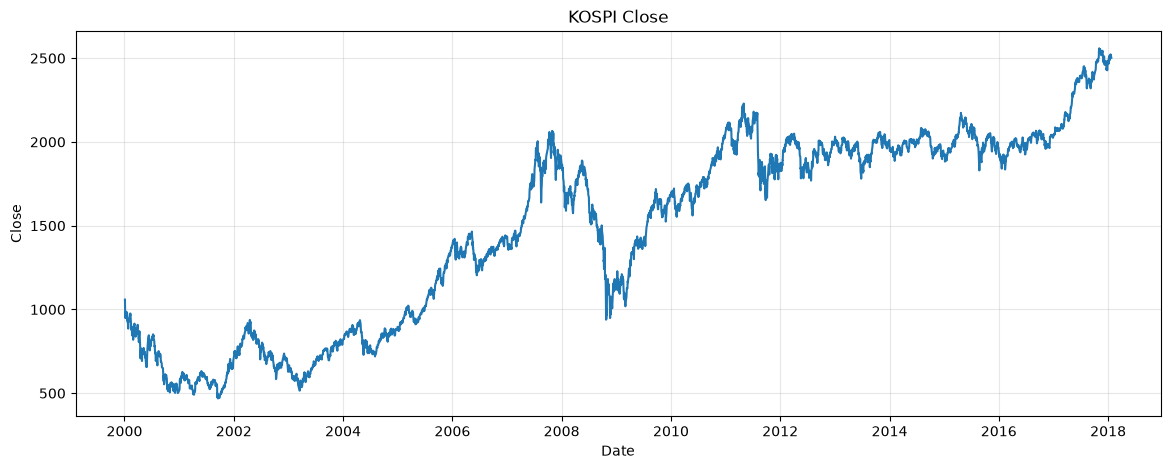

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Close"])
plt.title("KOSPI Close")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(alpha=0.3)
plt.show()

### Feature Engineering
RNN에 종가만 넣을 수도 있지만, 하루의 가격 구조와 최근 추세를 더 표현하기 위해 파생변수를 추가
- Open, High, Low, Close: 당일 가격 정보
- Return_1d: 전 거래일 대비 종가 수익률
- Range_pct: 당일 고가-저가 폭을 종가로 나눈 값
- OC_pct: 시가 대비 종가 변화율
- MA5_ratio: 현재 종가 / 최근 5일 이동평균
- MA20_ratio: 현재 종가 / 최근 20일 이동평균
- Volatility_10: 최근 10일 수익률의 표준편차

> 정답은 shift(-1)을 사용한 다음 거래일 종가

> 예를 들면, 현재 행이 t일이면 Feature: t일까지 계산 가능한 정보,  Target: t+1 거래일의  Close



In [18]:
data = df.copy()

data["Return_1d"] = data["Close"].pct_change()
data["Range_pct"] = (data["High"] - data["Low"]) / data["Close"]
data["OC_pct"] = (data["Close"] - data["Open"]) / data["Open"]

data["MA5"] = data["Close"].rolling(5).mean()
data["MA20"] = data["Close"].rolling(20).mean()

data["MA5_ratio"] = data["Close"] / data["MA5"]
data["MA20_ratio"] = data["Close"] / data["MA20"]

data["Volatility_10"] = data["Return_1d"].rolling(10).std()

# 다음 거래일 종가와 날짜를 정답으로 사용합니다.
data["Target_Close"] = data["Close"].shift(-1)
data["Target_Date"] = data["Date"].shift(-1)

FEATURES = [
    "Open",
    "High",
    "Low",
    "Close",
    "Return_1d",
    "Range_pct",
    "OC_pct",
    "MA5_ratio",
    "MA20_ratio",
    "Volatility_10",
]

# rolling으로 생긴 앞부분 NaN과 마지막 target NaN을 제거합니다.
data = data.dropna(subset=FEATURES + ["Target_Close", "Target_Date"]).reset_index(drop=True)

print("사용할 Feature 개수:", len(FEATURES))
print("정제 후 데이터 수:", len(data))
data[["Date"] + FEATURES + ["Target_Date", "Target_Close"]].head()

사용할 Feature 개수: 10
정제 후 데이터 수: 4432


,Date,Open,High,Low,Close,Return_1d,Range_pct,OC_pct,MA5_ratio,MA20_ratio,Volatility_10,Target_Date,Target_Close
0,2000-01-31,924.830017,948.840027,922.919983,943.880005,0.002347,0.027461,0.020598,1.032344,0.990929,0.025395,2000-02-01,928.750000
1,2000-02-01,955.440002,959.309998,923.520020,928.750000,-0.016030,0.038536,-0.027935,1.007524,0.981760,0.025668,2000-02-02,943.590027
2,2000-02-02,929.690002,950.130005,923.400024,943.590027,0.015978,0.028328,0.014951,1.010891,0.999704,0.022495,2000-02-03,950.219971
3,2000-02-03,950.260010,959.000000,934.109985,950.219971,0.007026,0.026194,-0.000042,1.009131,1.007292,0.022477,2000-02-07,973.130005
4,2000-02-07,953.229980,982.030029,951.309998,973.130005,0.024110,0.031568,0.020876,1.026602,1.030241,0.022042,2000-02-08,961.219971


# 데이터 분할
# Train / Validation / Test 분리
- 시계열에서 랜덤 분할하면 미래 시점의 데이터가 Train에 들어가고 과거 시점이 Test에 들어가는 비현실적인 평각가 될 수 있음
- 앞 70%를 Train, 다음 15% Validation, 마지막 15% Test로 나눔 

In [19]:
n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

print("Train rows :", train_end)
print("Valid rows :", val_end - train_end)
print("Test rows  :", n - val_end)

print()
print("Train target 기간:",
      data.loc[0, "Target_Date"], "~",
      data.loc[train_end - 1, "Target_Date"])

print("Valid target 기간:",
      data.loc[train_end, "Target_Date"], "~",
      data.loc[val_end - 1, "Target_Date"])

print("Test target 기간 :",
      data.loc[val_end, "Target_Date"], "~",
      data.loc[n - 1, "Target_Date"])

Train rows : 3102
Valid rows : 665
Test rows  : 665

Train target 기간: 2000-02-01 00:00:00 ~ 2012-08-20 00:00:00
Valid target 기간: 2012-08-21 00:00:00 ~ 2015-05-04 00:00:00
Test target 기간 : 2015-05-06 00:00:00 ~ 2018-01-22 00:00:00


### Scaling
- Open / High / Low / Close는 수백 또는 수천 단위 0에 가까운 소수이므로 그대로 학습하면 feature별 숫자 크기 차이가 큼
- StandardScaler를 사용하여 각 feature를 대략 평균 0, 표준편차 1이 되도록 변환
- Scaler의 평균과 표준편차를 Train 데이터만 계산 > Validation / Test까지 포함해 fit()하면 미래 데이터의 통계량을 미리 아는 데이터 누수가 됨


In [23]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()

# fit는 train에만 반영
# 기준을 계산해서 기억
scaler_x.fit(data.loc[:train_end - 1, FEATURES])
scaler_y.fit(data.loc[:train_end - 1, ['Target_Close']])

# transform은 전체 데이터에 반영
# 기억한 기준으로 실제 데이터를 변환
# 한번에 처리하는 함수는 fit_tramsform() <- 지금 이 코드에는 적용 X
X_all = scaler_x.transform(data[FEATURES]).astype(np.float32)
y_all = scaler_y.transform(data[['Target_Close']]).astype(np.float32)

print('X_all shape: ', X_all.shape)
print('y_all shape: ', y_all.shape)

X_all shape:  (4432, 10)
y_all shape:  (4432, 1)


# 시퀀스 만들기
- RNN은 한 행씩 독립적으로 보는 대신 연속된 여러 행을 하나의 샘플로 받음
- 예) SEQUENCE_LENGTH = 20이면 최근 20거래일을 하나의 window로 만듦
    - i = 19라면 입력은 0~19번 행이고 정답 y[19]는 19번 행의 다음 거래일 종가
    - i = 20이면 입력은 1~20번 행이 됨 > window가 하루씩 이동

> 전체 시계열에서 먼저 window를 만든 다음 정답이 속한 시점 기준으로 Train / Val / Test를 나눔.
<br> Validation / Test의 첫 예측에서도 직전 과거 구간을 입력  history로 사용할 수 있음

In [29]:
SEQUENCE_LENGTH = 20

def make_sequences(X, y, sequence_length):
    X_seq = []
    y_seq = []
    target_indices = []

    for i in range(sequence_length - 1, len(X)):
        start = i - sequence_length + 1
        X_seq.append(X[start:i+1])
        y_seq.append(y[i])
        target_indices.append(i)
    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.float32),
        np.asarray(target_indices, dtype=np.int64)
    )

In [31]:
X_seq, y_seq, target_indices = make_sequences(X_all, y_all, SEQUENCE_LENGTH)
print('전체 sequence shape: ', X_seq.shape)
print('전체 target shape: ', y_seq.shape)
print('target index shape: ', target_indices.shape)

전체 sequence shape:  (4413, 20, 10)
전체 target shape:  (4413, 1)
target index shape:  (4413,)
